In [5]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

In [6]:
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\Project\Sample_DATA.csv")
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Transaction_Frequency,647.0,3.564142,6.454543,0.00,1.000,2.00,3.00,50.00
Transaction_Amount_Deviation,647.0,5.014668,56.375914,-99.47,-42.355,8.38,52.29,99.45
Days_Since_Last_Transaction,647.0,15.717156,8.218122,1.00,8.500,16.00,23.00,29.00
amount,647.0,128.839753,364.995747,0.12,17.155,35.00,74.77,4883.62
fraud,647.0,0.239567,0.427150,0.00,0.000,0.00,0.00,1.00


In [7]:
df.duplicated().sum()
#no duplicate values

0

In [8]:
df.isnull().sum()

Transaction_ID                  0
Date                            0
Time                            0
Merchant_ID                     0
Customer_ID                     0
Device_ID                       0
Transaction_Type                0
Payment_Gateway                 0
Transaction_City                0
Transaction_State               0
IP_Address                      0
Transaction_Status              0
Device_OS                       0
Transaction_Frequency           0
Merchant_Category               0
Transaction_Channel             0
Transaction_Amount_Deviation    0
Days_Since_Last_Transaction     0
amount                          0
fraud                           0
dtype: int64

In [9]:
df.shape

(647, 20)

In [10]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%y')


Creating a new column 'Year' with the help of datetime module

In [11]:

df['Year'] = df['Date'].dt.year

Creating a month column with months of transaction

In [12]:
df['Month'] = df['Date'].dt.month
#df['Month'].sort_values(ascending=True).unique()
months = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

In [13]:
df['Month'].sort_values(ascending=True).unique()
df['Month'] = df['Month'].map(months)

In [14]:
#df.drop(['Date'], axis=1, inplace=True)
df.drop(['Time'], axis=1, inplace=True)

In [15]:
df['fraud'].value_counts(normalize=True)*100


fraud
0    76.043277
1    23.956723
Name: proportion, dtype: float64

<Axes: xlabel='fraud', ylabel='count'>

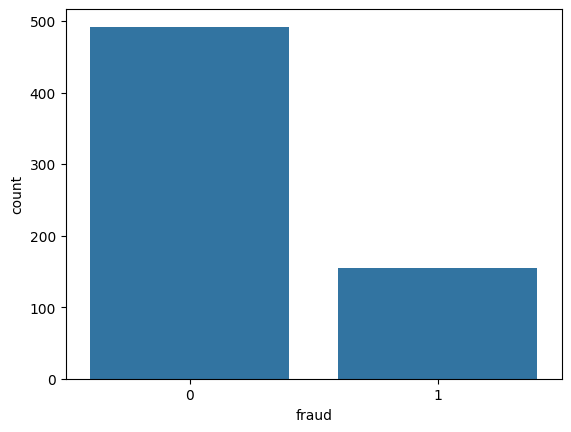

In [16]:
sns.countplot(x='fraud', data=df)

In [17]:
#fraud transactions dataset
fraud = df[df['fraud']==1]

fraud.shape

df.fraud.value_counts

<bound method IndexOpsMixin.value_counts of 0      1
1      1
2      1
3      1
4      1
      ..
642    0
643    0
644    0
645    0
646    0
Name: fraud, Length: 647, dtype: int64>

In [18]:
#normal transactions dataset
normal = df[df['fraud']==0]

normal.shape

(492, 21)

In [23]:
numeric_columns = fraud.select_dtypes(include=['int64', 'int32', 'float64'])
cat_columns = fraud.select_dtypes(include=['object'])
numeric_columns.corr()

,Transaction_Frequency,Transaction_Amount_Deviation,Days_Since_Last_Transaction,amount,fraud,Year
Transaction_Frequency,1.000000,0.112079,0.048399,-0.047628,NaN,-0.068477
Transaction_Amount_Deviation,0.112079,1.000000,-0.057579,-0.034097,NaN,-0.005956
Days_Since_Last_Transaction,0.048399,-0.057579,1.000000,0.078918,NaN,-0.003681
amount,-0.047628,-0.034097,0.078918,1.000000,NaN,0.022114
fraud,NaN,NaN,NaN,NaN,NaN,NaN
Year,-0.068477,-0.005956,-0.003681,0.022114,NaN,1.000000


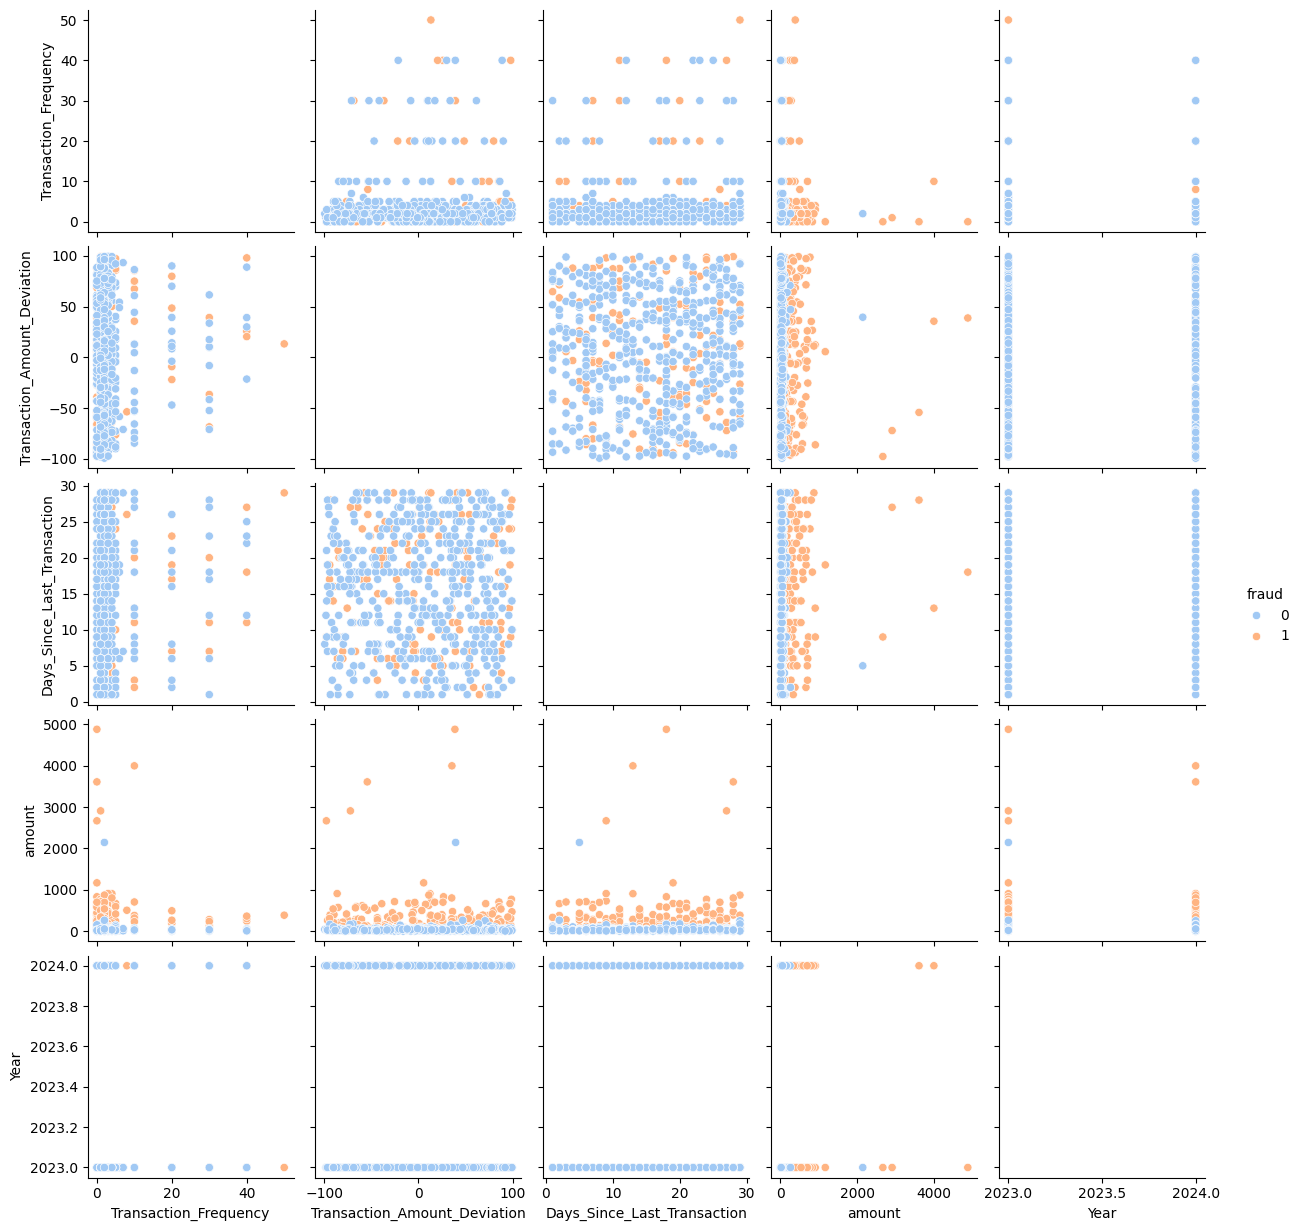

In [24]:
sns.pairplot(data=df, hue='fraud', palette = 'pastel', diag_kind='dist')

In [26]:
import plotly.express as px

fig = px.bar(x = fraud['Transaction_Type'].value_counts().index,
             y = fraud['Transaction_Type'].value_counts().values,
             color = fraud['Transaction_Type'].value_counts().index,
             title = 'Fraud Transaction Type Distribution',
             labels = {'x':'Transaction Type', 'y':'Count'},
             color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

In [29]:
fig = px.bar(
    x=fraud['Payment_Gateway'].value_counts().index,
    y=fraud['Payment_Gateway'].value_counts().values,
    color=fraud['Payment_Gateway'].value_counts().index,
    title='Fraud Payment Gateway Distribution',
    labels={'x':'Payment Gateway', 'y':'Count'},
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

In [30]:
fig = px.bar(x = fraud['Merchant_Category'].value_counts().index,
             y = fraud['Merchant_Category'].value_counts().values,
             color = fraud['Merchant_Category'].value_counts().index,
             title = 'Fraud Merchant Category Distribution',
             labels = {'x':'Merchant Category', 'y':'Count'},
             color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

In [33]:
fig = px.histogram(fraud, x='amount', nbins=50, title='Fraud Transaction Amount Distribution', labels={'amount':'Transaction Amount'})
fig.show()

In [35]:
fig = px.scatter(fraud, x='Transaction_Frequency', y='fraud',
                 title='Fraud Transaction Frequency Distribution',
                 labels={'Transaction_Frequency':'Transaction Frequency', 'fraud':'Fraud'},
                 color='fraud', color_discrete_map={0:'blue', 1:'red'})
fig.show()

In [36]:
fig = px.scatter(fraud, x='Days_Since_Last_Transaction', y='fraud',
                 title='Fraud Transaction Frequency Distribution',
                 labels={'Days_Since_Last_Transaction':'Days Since Last Transaction', 'fraud':'Fraud'},
                 color='fraud', color_discrete_map={0:'blue', 1:'red'})
fig.show()

In [37]:
fig = px.bar(
    x=fraud['Transaction_State'].value_counts().index,
    y=fraud['Transaction_State'].value_counts().values,
    color=fraud['Transaction_State'].value_counts().index,
    title='Fraud Transaction State Distribution',
    labels={'x':'Transaction State', 'y':'Count'},
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()

In [38]:
fig = px.bar(
    x=fraud['Device_OS'].value_counts().index,
    y=fraud['Device_OS'].value_counts().values,
    color=fraud['Device_OS'].value_counts().index,
    title='Fraud Device OS Distribution',
    labels={'x':'Device OS', 'y':'Count'},
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()